# Examen B1 - RI
## Leandro Bravo
## Gr1CC

## Librerías:

In [76]:
import kagglehub
import pandas as pd
from kagglehub import KaggleDatasetAdapter
import os
import matplotlib.pyplot as plt
import gensim.downloader as api
import sys
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from IPython.display import display
from pathlib import Path
current_dir = Path.cwd()
examen_root = current_dir.parent
prepro_dir = examen_root / '05prepro'

if str(prepro_dir) not in sys.path:
    sys.path.insert(0, str(prepro_dir))
from prepro_func import ensure_nltk_resources, remove_special_characters, tokenize
ensure_nltk_resources()

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## Paso 1: Cargar Corpus

In [10]:
path = kagglehub.dataset_download("stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset")

print("Path to dataset files:", path)
print("Dataset files downloaded successfully")

Path to dataset files: C:\Users\leand\.cache\kagglehub\datasets\stefanoleone992\rotten-tomatoes-movies-and-critic-reviews-dataset\versions\1
Dataset files downloaded successfully


## Paso 2: Selección de campos textuales

### Cargar datasets

In [20]:
print("Cargando datasets...")
movies_path = f"{path}/rotten_tomatoes_movies.csv"
reviews_path = f"{path}/rotten_tomatoes_critic_reviews.csv"

movies_df = pd.read_csv(movies_path)
reviews_df = pd.read_csv(reviews_path)

# Unimos utilizando 'rotten_tomatoes_link' 
df_merged = pd.merge(reviews_df, movies_df[['rotten_tomatoes_link', 'movie_title', 'genres']], 
                     on='rotten_tomatoes_link', 
                     how='inner')

# Seleccionamos los campos necesarios
df = df_merged[['genres', 'movie_title','review_content','critic_name']].dropna(subset=['review_content']).reset_index(drop=True)
df.insert(0, 'Document ID', df.index.map(lambda i: f"Movie_{i}"))

corpus_df = df.copy()
corpus_df

Cargando datasets...


,Document ID,genres,movie_title,review_content,critic_name
0,Movie_0,"Action & Adventure, Comedy, Drama, Science Fic...",Percy Jackson & the Olympians: The Lightning T...,A fantasy adventure that fuses Greek mythology...,Andrew L. Urban
1,Movie_1,"Action & Adventure, Comedy, Drama, Science Fic...",Percy Jackson & the Olympians: The Lightning T...,"Uma Thurman as Medusa, the gorgon with a coiff...",Louise Keller
2,Movie_2,"Action & Adventure, Comedy, Drama, Science Fic...",Percy Jackson & the Olympians: The Lightning T...,With a top-notch cast and dazzling special eff...,NaN
3,Movie_3,"Action & Adventure, Comedy, Drama, Science Fic...",Percy Jackson & the Olympians: The Lightning T...,Whether audiences will get behind The Lightnin...,Ben McEachen
4,Movie_4,"Action & Adventure, Comedy, Drama, Science Fic...",Percy Jackson & the Olympians: The Lightning T...,What's really lacking in The Lightning Thief i...,Ethan Alter
...,...,...,...,...,...
1064104,Movie_1064104,"Classics, Drama",Zulu,A rousing reconstruction of the 1879 Battle of...,Joan Didion
1064105,Movie_1064105,"Action & Adventure, Art House & International,...",Zulu Dawn,"Seen today, it's not only a startling indictme...",Ken Hanke
1064106,Movie_1064106,"Action & Adventure, Art House & International,...",Zulu Dawn,A rousing visual spectacle that's a prequel of...,Dennis Schwartz
1064107,Movie_1064107,"Action & Adventure, Art House & International,...",Zulu Dawn,"A simple two-act story: Prelude to war, and th...",Christopher Lloyd


## Paso 3: Preprocesamiento

In [27]:
# Minúsculas
corpus_df['cleaned_review'] = corpus_df['review_content'].apply(lambda x: x.lower())

In [28]:
# Eliminamos caracteres especiales
corpus_df['cleaned_review'] = corpus_df['review_content'].apply(lambda x: remove_special_characters(x))

## Paso 4: Embeddings

### Cargar modelo

In [34]:
model = SentenceTransformer('all-MiniLM-L6-v2')

C:\Users\leand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\leand\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading w

Muestra de 100K de los datos para tener el 10% de estos y que sea más signinficativo el ejercicio

In [73]:
# Toma una muestra aleatoria de 100000 filas
subset_df = corpus_df.sample(n=100000, random_state=42).reset_index(drop=True)
subset_reviews = subset_df['cleaned_review'].tolist()
# Genera los embeddings para la muestra
embeddings = model.encode(subset_reviews, show_progress_bar=True)

Batches: 100%|██████████| 3125/3125 [04:09<00:00, 12.52it/s]


## Paso 5: Procesamiento de consultas

In [74]:
def recuperacion(query, embeddings, dataset, top_k=10):
    query_clean = remove_special_characters(query.lower())
    query_embedding = model.encode([query_clean])
    similarities = cosine_similarity(query_embedding, embeddings).flatten()
    top_indices = np.argsort(similarities)[-top_k:][::-1]
    df_resultados = dataset.iloc[top_indices].copy()
    
    ranking_df = pd.DataFrame({
        'Ranking': range(1, len(top_indices) + 1),
        'ID documento': df_resultados['Document ID'],
        'Título película': df_resultados['movie_title'],
        'Fragmento de texto': df_resultados['cleaned_review'],
        'Similitud': similarities[top_indices]
    })
    
    return ranking_df.reset_index(drop=True)

## Paso 6: Benchmark de consultas

In [78]:
queries = [ 
    "science fiction movie with advanced technology",
    "romantic story with emotional relationships",
    "action movie with intense fight scenes",
    "horror film that creates fear and suspense",
    "visually impressive movie with weak storyline",
    "emotionally moving performance by the lead actor",
    "predictable plot but entertaining experience",
    "movie praised by critics but unpopular with audiences"
]

resumen_general = []

for query in queries:
    df_resultados = recuperacion(query, embeddings, subset_df, top_k=10)
    
    print("\n")
    print(f"Consulta: '{query}'")
    
    display(df_resultados)
    
    top_1 = df_resultados.iloc[0]
    resumen_general.append({
        'Consulta': f"Q{queries.index(query) + 1}",
        'Documento Top-1': top_1['ID documento'],
        'Título película': top_1['Título película'],
        'Similitud': top_1['Similitud']
    })



Consulta: 'science fiction movie with advanced technology'


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,Movie_730693,Serenity,A science fiction movie for adults,0.660716
1,2,Movie_165004,Big Hero 6,a terrific film in its first half where screen...,0.626194
2,3,Movie_173102,Blade Runner,A masterpiece of dystopian science fiction on ...,0.600886
3,4,Movie_1012253,Valerian and the City of a Thousand Planets,One of the most gorgeous science fiction movie...,0.594064
4,5,Movie_857992,The Terminator,TECHu2022NOIR indeed Hes a futuristic machine ...,0.571110
5,6,Movie_220379,Children of Men,one of the best science fiction films in the p...,0.564718
6,7,Movie_170167,Black Narcissus,It might be the most beautiful film ever done ...,0.551503
7,8,Movie_498126,Looper,This is a you know what would be cool movie th...,0.551344
8,9,Movie_273321,Divergent,A good young adult movie in the dystopian vein...,0.551014
9,10,Movie_539166,Minority Report,Ferociously intense furiously kinetic its expr...,0.548792




Consulta: 'romantic story with emotional relationships'


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,Movie_979453,Three Times (Zui hao de shi guang),An emotionally understated giant of a love story,0.701187
1,2,Movie_123243,Animals,A deeply human and heartbreaking love story,0.690070
2,3,Movie_270815,Dirty Pretty Things,The best romantic love story Ive seen so far t...,0.679929
3,4,Movie_110909,All the Real Girls,A smartly acted achingly simple love story,0.672194
4,5,Movie_865381,The Aftermath,A turbulent love story that wallows in sadness,0.651322
5,6,Movie_352145,Gloria,Awardwinning performance and strong emotional ...,0.639771
6,7,Movie_1025922,Warm Bodies,A whimsical charming love story,0.638626
7,8,Movie_503749,Love the Hard Way,Wildly uneven romantic drama,0.634701
8,9,Movie_100590,Adrift,A simple acutely observed love story that also...,0.629262
9,10,Movie_504604,Loving,Inspirational true love story,0.627616




Consulta: 'action movie with intense fight scenes'


...

,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,Movie_571178,Night Moves,The actors give downtoearth but emotionally ch...,0.655401
1,2,Movie_700238,Rush,Exhilarating in parts and immensely moving in ...,0.624873
2,3,Movie_826754,Stir of Echoes,Disturbing imagery great timing and strong act...,0.612850
3,4,Movie_690579,Roma,Astoundingly this is Aparicios acting debut It...,0.610939
4,5,Movie_758118,The Silence of the Lambs,It is a masterclass of acting directing writin...,0.608600
5,6,Movie_363194,The Great New Wonderful,Why is such a talented cast doing such weak ma...,0.604969
6,7,Movie_186894,Brad's Status,The films emotional beats are strangely resona...,0.602634
7,8,Movie_573209,Nixon,A brilliantly complex character study with a d...,0.600014
8,9,Movie_297392,Enduring Love,An actors movie and the three leads give shatt...,0.599449
9,10,Movie_726506,Seeking a Friend for the End of the World,One of the years most emotionally affecting mo...,0.592548




Consulta: 'predictable plot but entertaining experience'


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,Movie_535698,Midsommar,But I found it impossible to appreciate the pl...,0.737379
1,2,Movie_43318,Trapped,Never engaging utterly predictable and complet...,0.735571
2,3,Movie_326846,Focus,Entertaining and surprisingly unpredictable,0.733790
3,4,Movie_328744,Forces of Nature,For the most part this film is not particularl...,0.732343
4,5,Movie_732383,Seven Days In Utopia,Great actors and good messages but very predic...,0.726626
5,6,Movie_27183,Scent of a Woman,While fairly predictable and unoriginal it is ...,0.722431
6,7,Movie_569333,New York Minute,The film rests on a contrived and predictable ...,0.700036
7,8,Movie_84337,88 Minutes,An enjoyable thriller for those who dont worry...,0.699215
8,9,Movie_195105,Brother Bear,The story is so predictable,0.688194
9,10,Movie_19609,Invasion of the Body Snatchers,Very entertaining and despite the by now over ...,0.682311




Consulta: 'movie praised by critics but unpopular with audiences'


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,Movie_28116,The Kid,Critics at the time praised the film for its e...,0.710030
1,2,Movie_945690,The Prey,It is not so much about this movie being bad a...,0.681673
2,3,Movie_1019673,Vox Lux,Honestly in writing the review I came to like ...,0.673742
3,4,Movie_341924,Garfield: A Tail of Two Kitties,Where the first movie was bad in that it was a...,0.665548
4,5,Movie_189797,Bride and Prejudice,While the film is slightly flawed it is imposs...,0.660482
5,6,Movie_648820,Rampage,No satisfying action beats no memorable images...,0.656312
6,7,Movie_578953,Now You See Me,Despite decent performances this is a hugely d...,0.652992
7,8,Movie_191819,Bright,Critics are foolish to believe they have the c...,0.652671
8,9,Movie_40242,Pearl Harbor,A disappointing film because it simply doesnt ...,0.645358
9,10,Movie_312836,Fast & Furious Presents: Hobbs & Shaw,Its difficult to dislike a movie in which ever...,0.643611


## Paso 7: Tablas Resumen

In [79]:
df_resumen = pd.DataFrame(resumen_general)
display(df_resumen)

,Consulta,Documento Top-1,Título película,Similitud
0,Q1,Movie_730693,Serenity,0.660716
1,Q2,Movie_979453,Three Times (Zui hao de shi guang),0.701187
2,Q3,Movie_467137,Kung Fu Killer,0.696688
3,Q4,Movie_873905,The Blob,0.851562
4,Q5,Movie_468926,La La Land,0.717623
5,Q6,Movie_571178,Night Moves,0.655401
6,Q7,Movie_535698,Midsommar,0.737379
7,Q8,Movie_28116,The Kid,0.710030


## Desafío de Excelencia
## Paso 8: Visualización PCA

In [81]:
# Reducimos Dimensionalidad
pca = PCA(n_components=2, random_state=42)
doc_embeddings_2d = pca.fit_transform(embeddings)

In [83]:
# Generamos embeddings para las consultas
queries_clean = [remove_special_characters(q.lower()) for q in queries]
query_embeddings = model.encode(queries_clean)
query_embeddings_2d = pca.transform(query_embeddings)

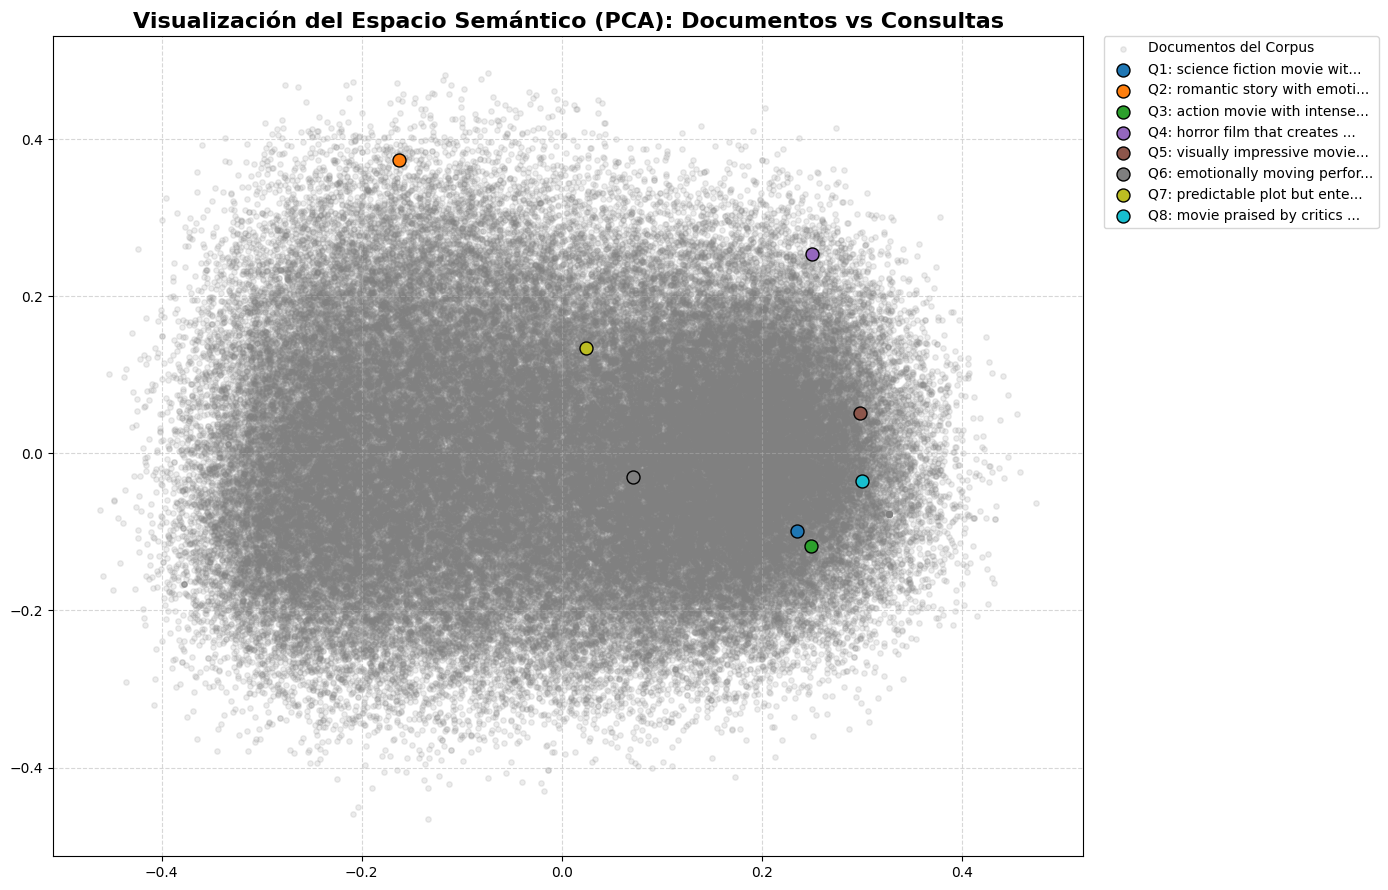

In [88]:
# Graficamos
plt.figure(figsize=(14, 9))
plt.scatter(doc_embeddings_2d[:, 0], doc_embeddings_2d[:, 1], 
            alpha=0.15, color='gray', label='Documentos del Corpus', s=15)
colores = plt.cm.tab10(np.linspace(0, 1, len(queries))) # Paleta de colores diferenciada

for i, (q_2d, color, query_text) in enumerate(zip(query_embeddings_2d, colores, queries)):
    plt.scatter(q_2d[0], q_2d[1], 
                color=color, 
                edgecolors='black', 
                s=350,
                marker='.', 
                label=f'Q{i+1}: {query_text[:25]}...')

plt.title('Visualización del Espacio Semántico (PCA): Documentos vs Consultas', fontsize=16, fontweight='bold')

# Leyenda
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()